# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [3]:
df.columns

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='object')

In [4]:
df.dtypes

num_passengers             int64
sales_channel             object
trip_type                 object
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                object
route                     object
booking_origin            object
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [6]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [7]:
df.columns

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='object')

In [8]:
# Convert object columns to categorical dtype in df
object_cols = ['booking_complete','wants_extra_baggage', 'wants_preferred_seat','wants_in_flight_meals','sales_channel', 'trip_type','flight_day','booking_origin']
df[object_cols] = df[object_cols].astype('category')
df.dtypes

num_passengers              int64
sales_channel            category
trip_type                category
purchase_lead               int64
length_of_stay              int64
flight_hour                 int64
flight_day               category
route                      object
booking_origin           category
wants_extra_baggage      category
wants_preferred_seat     category
wants_in_flight_meals    category
flight_duration           float64
booking_complete         category
dtype: object

In [9]:
import plotly.express as px

In [ ]:
df1 = df.select_dtypes(include=['number'])
px.box(df1)

In [ ]:
df.columns

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='object')

In [ ]:
import numpy as np
# Calculate Q1, Q3, and IQR for each column in outcols
outcols = ['num_passengers', 'purchase_lead','length_of_stay']
Q1 = df[outcols].quantile(0.25)
Q3 = df[outcols].quantile(0.75)
IQR = Q3 - Q1
print(Q1, Q3, IQR)
# Define bounds
lbound = Q1 - 1.5 * IQR
ubound = Q3 + 1.5 * IQR
print(lbound, ubound)
# Replace outliers with the respective bounds for each column
for col in outcols:
    df[col] = np.where(df[col] > ubound[col], ubound[col],
                       np.where(df[col] < lbound[col], lbound[col], df[col]))
px.box(df[outcols])

num_passengers     1.0
purchase_lead     21.0
length_of_stay     5.0
Name: 0.25, dtype: float64 num_passengers      2.0
purchase_lead     115.0
length_of_stay     28.0
Name: 0.75, dtype: float64 num_passengers     1.0
purchase_lead     94.0
length_of_stay    23.0
dtype: float64
num_passengers     -0.5
purchase_lead    -120.0
length_of_stay    -29.5
dtype: float64 num_passengers      3.5
purchase_lead     256.0
length_of_stay     62.5
dtype: float64


C:\Users\venka\AppData\Local\Temp\ipykernel_7136\4029840265.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




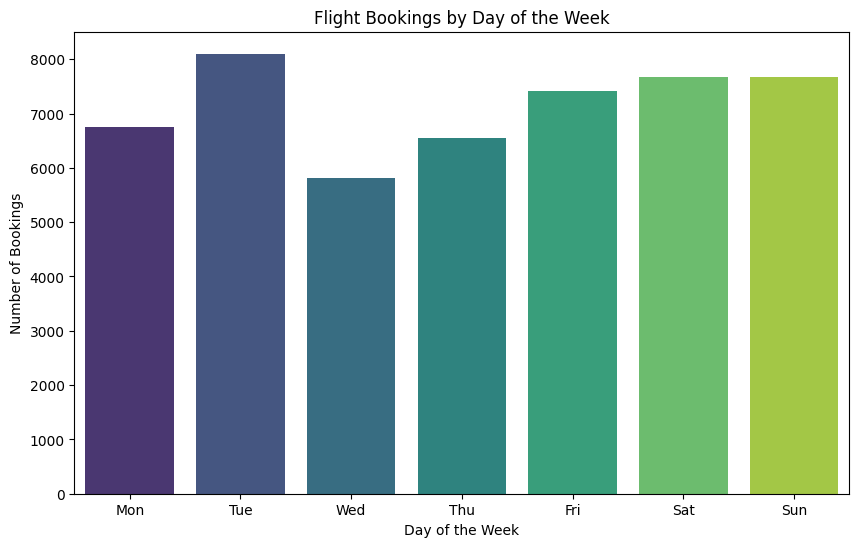

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(x="flight_day", data=df, palette="viridis")
plt.title("Flight Bookings by Day of the Week")
plt.xlabel("Day of the Week")       
plt.ylabel("Number of Bookings")
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.show()  


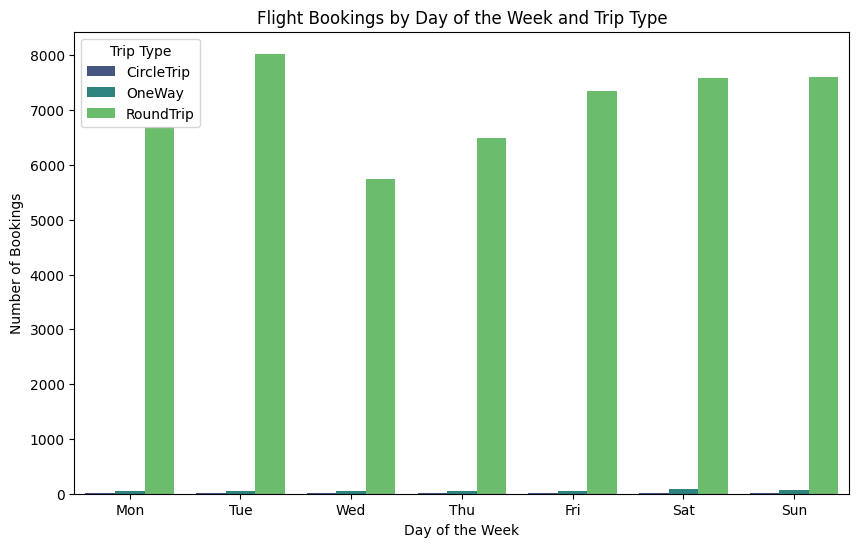

<Figure size 1000x600 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x="flight_day", hue="trip_type", data=df, palette="viridis")
plt.title("Flight Bookings by Day of the Week and Trip Type")   
plt.xlabel("Day of the Week")
plt.ylabel("Number of Bookings")
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.legend(title="Trip Type")
plt.show()
plt.figure(figsize=(10, 6))
plt.show()


C:\Users\venka\AppData\Local\Temp\ipykernel_7136\1673444183.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




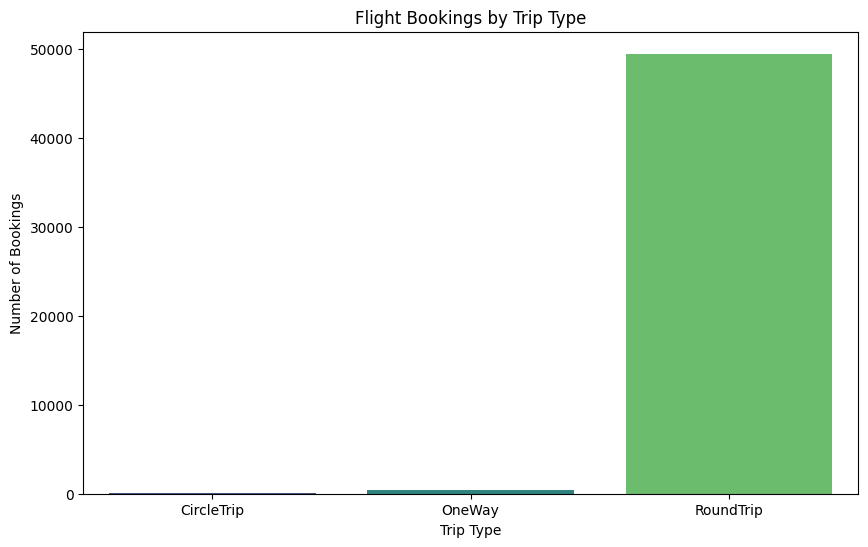

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["trip_type"] = le.fit_transform(df["trip_type"])
df["trip_type"].unique()
df["trip_type"].value_counts()
plt.figure(figsize=(10, 6))
sns.countplot(x="trip_type", data=df, palette="viridis")
plt.title("Flight Bookings by Trip Type")
plt.xlabel("Trip Type")
plt.ylabel("Number of Bookings")
plt.xticks(ticks=range(len(df["trip_type"].unique())), labels=le.classes_)
plt.show()

In [ ]:
df["trip_type"].value_counts()/len(df)

trip_type
2    0.98994
1    0.00774
0    0.00232
Name: count, dtype: float64

In [ ]:
from sklearn.utils import resample

df_majority = df[df['trip_type'] == 2]
df_minority = df[df['trip_type'] != 2]

df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority)*2,
                                   random_state=42)

df_balanced = pd.concat([df_majority_downsampled, df_minority])

df_balanced["trip_type"].value_counts()/len(df_balanced)


trip_type
2    0.666667
1    0.256461
0    0.076872
Name: count, dtype: float64

In [ ]:
df_balanced

In [ ]:
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder()
df_balanced["trip_type"] = le.fit_transform(df_balanced["trip_type"])
df_balanced["flight_day"] = le.fit_transform(df_balanced["flight_day"])
df_balanced["booking_origin"] = le.fit_transform(df_balanced["booking_origin"])
df_balanced["sales_channel"] = le.fit_transform(df_balanced["sales_channel"])
df_balanced["booking_complete"] = le.fit_transform(df_balanced["booking_complete"])
df_balanced["wants_extra_baggage"] = le.fit_transform(df_balanced["wants_extra_baggage"])
df_balanced["wants_preferred_seat"] = le.fit_transform(df_balanced["wants_preferred_seat"])
df_balanced["wants_in_flight_meals"] = le.fit_transform(df_balanced["wants_in_flight_meals"])
df_balanced["route"] = le.fit_transform(df_balanced["route"])
df_balanced.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
298,1.0,1,2,15.0,62.5,13,0,4,10,1,0,1,8.83,0
38858,1.0,0,2,32.0,5.0,17,0,182,16,1,1,1,7.57,1
11953,3.5,0,2,103.0,18.0,11,4,167,1,1,0,0,8.83,0
7207,3.0,0,2,195.0,30.0,0,3,74,1,1,1,1,8.58,0
2027,2.0,0,2,256.0,17.0,15,3,4,19,0,0,0,8.83,1


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import joblib

# Preprocess
scaler = StandardScaler()
y = df_balanced['trip_type']
X = scaler.fit_transform(df_balanced.drop(columns=['trip_type']))
X = pd.DataFrame(X, columns=df_balanced.drop(columns=['trip_type']).columns)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, criterion='gini'),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Fit the best model
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# Print best params
print("Best Parameters Found:", grid_search.best_params_)

# Evaluate
y_pred = best_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save & Load
joblib.dump(best_model, "flight_booking_model.pkl")
model = joblib.load("flight_booking_model.pkl")

# Predict sample
sample_data = X_test.iloc[[0]]
predicted_trip_type = model.predict(sample_data)
print(f"Predicted Trip Type: {predicted_trip_type[0]}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters Found: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

           0       0.08      0.04      0.06        23
           1       0.66      0.59      0.62        78
           2       0.81      0.88      0.84       201

    accuracy                           0.74       302
   macro avg       0.51      0.50      0.51       302
weighted avg       0.71      0.74      0.73       302

Confusion Matrix:
[[  1   7  15]
 [  5  46  27]
 [  7  17 177]]
Predicted Trip Type: 2
